## BIO597 Spatial Analysis of Biodiversity Fall 2026


### How to inspect instantiated variables in jupyter notebooks
Quickly following up on a question from last week. There are two ways to inspect instantiated variables in jupyter notebooks. One way is to use the `%whos` magic command (magic commands are special things that jupyter notebooks do for you that are unrelated to python or the underlying operating system).

In [1]:
fruits = ["apple", "tomato", "peach"]
veggies = ["beet", "potato", "tomato"]

In [2]:
%whos

Variable   Type    Data/Info
----------------------------
fruits     list    n=3
veggies    list    n=3


#### Turn on debugging
The other way is to turn on debugging and open the 'variables' pane in the debug panel.

\<Demonstration goes here>

# Biodiversity data cleaning

## Goals for today

This notebook introduces basic concepts for cleaning and quality control of occurrence records. These methods and concepts will be applicable to any species occurrence dataset, but it's especially important when downloading data from GBIF, because the records can be very heterogeneous in quality.

By the end of this lab you should be able to:

* Remove records with missing or invalid coordinates — Exclude records lacking usable latitude/longitude or containing malformed values.
* Check coordinate ranges — Remove coordinates outside valid geographic bounds or with latitude/longitude accidentally swapped.
* Remove duplicate records — Deduplicate identical or near-identical observations, depending on the analysis.
* Verify taxonomic identification — Standardize species names and flag records with unresolved, outdated, or questionable identifications.
* Filter by coordinate uncertainty — Exclude records whose positional uncertainty is too large for the spatial scale of the analysis.
* Remove obvious spatial outliers — Flag records far outside the known or plausible geographic range for the species.
* Check for points in unlikely locations — Identify records in oceans, administrative centroids, country capitals, or other common geocoding errors.
* Filter by sampling date — Remove records outside the study period or with insufficiently precise dates for the research question.

### Example dataset: Malagasy Leaf-nosed Snake (*Langaha madagascariensis*)
Sticking with the snake theme we will look at occurrence data for the genus *Langaha*, a monotypic genus endemic to Madagascar. The Malagasy Leaf-nosed Snake [*Langaha madagascariensis*](https://snakesarelong.blogspot.com/2013/02/malagasy-leaf-nosed-snakes.html) is the sole species within this genus and it displays a striking (and yet to be explained) sexual dimorphism.

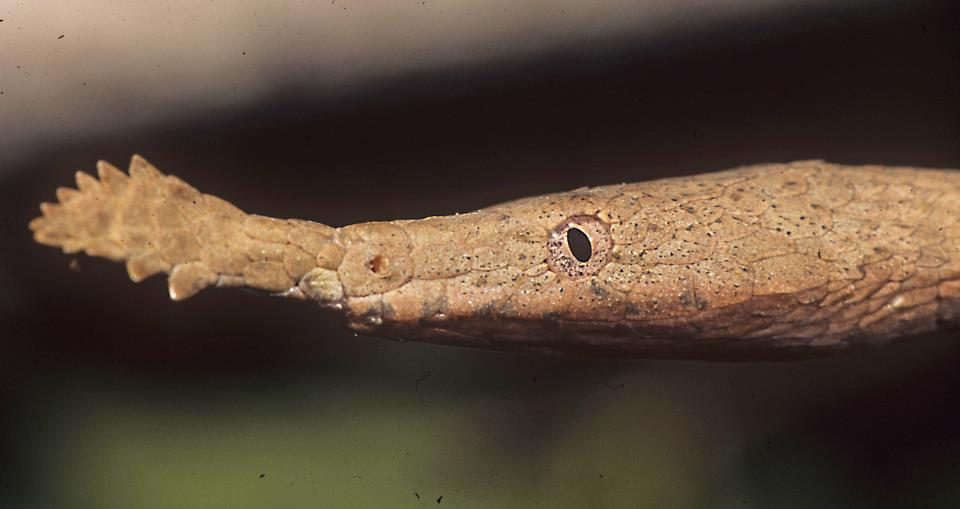

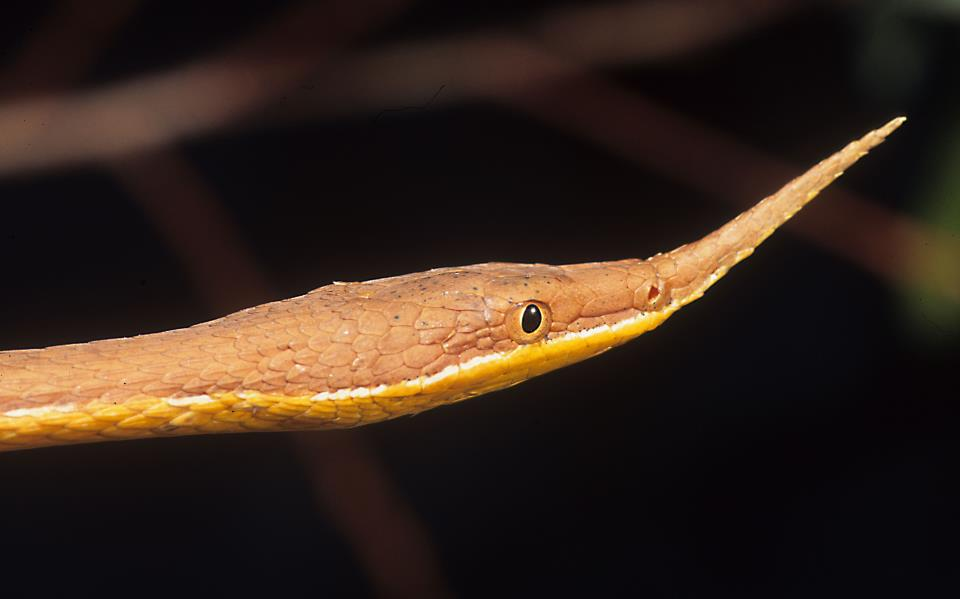

### A quick note about citations

GBIF data should be cited when used in reports, publications, or assignments. The proper citation format for [GBIF data](https://doi.org/10.15468/dl.y98fz3) used in this exercise is:
```
GBIF.org (16 September 2026) GBIF Occurrence Download https://doi.org/10.15468/dl.y98fz3
```

## 1. Import packages

We will use `pandas` for table cleaning and `geopandas` for mapping points.

The data file is a GBIF occurrence download. Even though the file ends in `.csv`, it is tab-delimited, so we will use `sep="	"` when we read it.


In [2]:
import pandas as pd
import geopandas as gpd

## 2. Load the occurrence records

Start by reading the file and looking at the first few rows. The original file has many columns because GBIF exports a lot of metadata with each record.


In [3]:
# GBIF data is tab-separated by default so we need to this to pandas with: `sep="\t"`
langaha = pd.read_csv("Langaha/Langaha-Occurrences.csv", sep="\t")
langaha.head()

,gbifID,datasetKey,occurrenceID,kingdom,phylum,class,order,family,genus,species,...,identifiedBy,dateIdentified,license,rightsHolder,recordedBy,typeStatus,establishmentMeans,lastInterpreted,mediaType,issue
0,6480631394,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/38899...,Animalia,Chordata,Reptilia,Squamata,Pseudoxyrhophiidae,Langaha,Langaha pseudoalluaudi,...,Fionn Ó Marcaigh,2026-08-07T10:43:52,CC0_1_0,Fionn Ó Marcaigh,Fionn Ó Marcaigh,NaN,NaN,2026-09-11T06:15:32.022Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
1,6480068948,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/30741...,Animalia,Chordata,Reptilia,Squamata,Pseudoxyrhophiidae,Langaha,Langaha madagascariensis,...,Nathalie Jreidini,2025-08-19T01:53:20,CC_BY_NC_4_0,Nathalie Jreidini,Nathalie Jreidini,NaN,NaN,2026-09-11T06:05:41.617Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
2,6431436926,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/37793...,Animalia,Chordata,Reptilia,Squamata,Pseudoxyrhophiidae,Langaha,Langaha madagascariensis,...,Leonard Spohr,2026-07-04T03:53:38,CC_BY_4_0,Leonard Spohr,Leonard Spohr,NaN,NaN,2026-09-11T05:59:03.393Z,NaN,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
3,6400873326,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/37060...,Animalia,Chordata,Reptilia,Squamata,Pseudoxyrhophiidae,Langaha,Langaha madagascariensis,...,naturalistchu,2026-06-11T12:38:48,CC_BY_NC_4_0,naturalistchu,naturalistchu,NaN,NaN,2026-09-11T05:49:05.511Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
4,6399836759,50c9509d-22c7-4a22-a47d-8c48425ef4a7,https://www.inaturalist.org/observations/37010...,Animalia,Chordata,Reptilia,Squamata,Pseudoxyrhophiidae,Langaha,Langaha madagascariensis,...,ns777,2026-06-09T18:48:27,CC_BY_NC_4_0,ns777,ns777,NaN,NaN,2026-09-11T05:37:18.252Z,StillImage,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...


## 3. Inspect the size of the dataset

Before cleaning data, always ask how many rows and columns you have. This gives you a baseline for later, when records are removed by cleaning steps.


In [4]:
langaha.shape
## 263 rows
## 50 columns

(263, 50)

## 4. Look at the column names

GBIF data can feel overwhelming because there are many columns. Looking at the column names helps us decide which fields are useful for this lab.


In [5]:
langaha.columns

Index(['gbifID', 'datasetKey', 'occurrenceID', 'kingdom', 'phylum', 'class',
       'order', 'family', 'genus', 'species', 'infraspecificEpithet',
       'taxonRank', 'scientificName', 'verbatimScientificName',
       'verbatimScientificNameAuthorship', 'countryCode', 'locality',
       'stateProvince', 'occurrenceStatus', 'individualCount',
       'publishingOrgKey', 'decimalLatitude', 'decimalLongitude',
       'coordinateUncertaintyInMeters', 'coordinatePrecision', 'elevation',
       'elevationAccuracy', 'depth', 'depthAccuracy', 'eventDate', 'day',
       'month', 'year', 'taxonKey', 'speciesKey', 'basisOfRecord',
       'institutionCode', 'collectionCode', 'catalogNumber', 'recordNumber',
       'identifiedBy', 'dateIdentified', 'license', 'rightsHolder',
       'recordedBy', 'typeStatus', 'establishmentMeans', 'lastInterpreted',
       'mediaType', 'issue'],
      dtype='str')

## 5. Keep a smaller set of useful columns

For this lab keep columns related to identity, location, date, record type, and GBIF data quality flags.

Reducing the number of columns makes the table easier to inspect while we learn the cleaning workflow.

**Remember:** Pandas dataframes are tables with one row per record and one column per metadata field.
You can subset a dataframe by passing in a list only the column names to keep, which is what we do
in the next cell.

In [6]:
columns_to_keep = [ ## Defining columns_to_keep as a list
    "gbifID",
    "occurrenceID",
    "genus",
    "species",
    "scientificName",
    "countryCode",
    "stateProvince",
    "locality",
    "decimalLatitude",
    "decimalLongitude",
    "coordinateUncertaintyInMeters",
    "eventDate",
    "year",
    "basisOfRecord",
    "institutionCode",
    "collectionCode",
    "catalogNumber",
    "issue",
]

## Idea is that we create a list of column names to keep, then apply that list to the dataframe (next line)
langaha = langaha[columns_to_keep] ## Subsets langaha dataframe using columns_to_keep
langaha.head()
## Notice: multiple species, coordinateUncertaintyInMeters - some are reasonable (small, <1km) some are very large (30km)

,gbifID,occurrenceID,genus,species,scientificName,countryCode,stateProvince,locality,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,eventDate,year,basisOfRecord,institutionCode,collectionCode,catalogNumber,issue
0,6480631394,https://www.inaturalist.org/observations/38899...,Langaha,Langaha pseudoalluaudi,"Langaha pseudoalluaudi Domergue, 1988",MG,Mahajanga,NaN,-15.487104,46.647066,85.0,2018-07-02T14:35,2018.0,HUMAN_OBSERVATION,iNaturalist,Observations,388992628,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
1,6480068948,https://www.inaturalist.org/observations/30741...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Toamasina,NaN,-17.800565,48.799507,NaN,2024-10-24T09:52,2024.0,HUMAN_OBSERVATION,iNaturalist,Observations,307416317,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
2,6431436926,https://www.inaturalist.org/observations/37793...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Antsiranana,NaN,-15.704636,49.885004,30870.0,2019-08-11T17:41:09,2019.0,HUMAN_OBSERVATION,iNaturalist,Observations,377938430,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
3,6400873326,https://www.inaturalist.org/observations/37060...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Mahajanga,NaN,-19.139489,44.811955,NaN,2026-06-11T11:29:32,2026.0,HUMAN_OBSERVATION,iNaturalist,Observations,370606880,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...
4,6399836759,https://www.inaturalist.org/observations/37010...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Toamasina,NaN,-18.599154,49.208611,638.0,2024-05-08T21:45,2024.0,HUMAN_OBSERVATION,iNaturalist,Observations,370105301,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...


## 6. Make a simple cleaning log

As we clean the data, we will record how many records remain after important steps. This is a good habit because it makes your workflow easier to explain later.


In [7]:
cleaning_log = []

cleaning_log.append({"step": "raw records", "n_records": len(langaha)})
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263


## 7. Check taxonomic names

Before mapping or filtering coordinates, check which species names are present. This dataset is for the genus *Langaha*, but it includes more than one species name.


In [8]:
langaha["species"].value_counts(dropna=False)

species
Langaha madagascariensis    247
Langaha alluaudi             13
Langaha pseudoalluaudi        3
Name: count, dtype: int64

In [9]:
# Get a list of True/False per row based on whether the record is L. madagascariensis
is_madagascariensis = langaha["species"] == "Langaha madagascariensis" ## Defining a variable that tests equality (==) based on the defined option 

# Filter the dataframe on these species ID boolean values
langaha = langaha[is_madagascariensis]

# Update the cleaning log
cleaning_log.append({"step": "only L. madagascariensis", "n_records": len(langaha)})
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263
1,only L. madagascariensis,247


## 8. Check record types

The `basisOfRecord` column tells us what kind of occurrence record each row represents. Examples include preserved specimens and human observations.

Different analyses may use different record types, so it is useful to inspect this column early.


In [10]:
langaha["basisOfRecord"].value_counts(dropna=False)

basisOfRecord
PRESERVED_SPECIMEN     176
HUMAN_OBSERVATION       69
MATERIAL_SAMPLE          1
MACHINE_OBSERVATION      1
Name: count, dtype: int64

## 9. Check country codes

*Langaha* is endemic to Madagascar. Madagascar has the country code `MG` in GBIF.

If we see records from other countries, those records need closer inspection.


In [12]:
langaha["countryCode"].value_counts(dropna=False)
## We'll get to removing Nan, ZZ, and US in a moment

countryCode
MG     233
NaN      9
ZZ       4
US       1
Name: count, dtype: int64

## 10. Convert coordinate columns to numbers

Sometimes coordinate columns are read as text, especially when files contain missing values. `pd.to_numeric()` makes sure Python treats these columns as numbers.

The option `errors="coerce"` turns values that cannot be interpreted as numbers into missing values.


In [ ]:
## Convert decimal to numeric
## Discard records that do not have lat/long data (next step)
langaha["decimalLatitude"] = pd.to_numeric(langaha["decimalLatitude"], errors="coerce") ##Converting column into numeric values
langaha["decimalLongitude"] = pd.to_numeric(langaha["decimalLongitude"], errors="coerce")
langaha["coordinateUncertaintyInMeters"] = pd.to_numeric(langaha["coordinateUncertaintyInMeters"], errors="coerce")
langaha["year"] = pd.to_numeric(langaha["year"], errors="coerce")

langaha[["decimalLatitude", "decimalLongitude", "coordinateUncertaintyInMeters", "year"]].head(10)

,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,year
1,-17.800565,48.799507,NaN,2024.0
2,-15.704636,49.885004,30870.0,2019.0
3,-19.139489,44.811955,NaN,2026.0
4,-18.599154,49.208611,638.0,2024.0
5,-19.139483,44.812350,2.0,2026.0
6,NaN,NaN,NaN,NaN
7,-12.974682,49.714605,31.0,2017.0
8,-18.627254,49.205436,350.0,2026.0
9,-18.679154,49.215714,30632.0,2025.0
10,-13.035830,49.556068,122.0,2017.0


## 11. Find records with missing coordinates

Records without latitude or longitude cannot be mapped directly. They may still be useful for some questions, but they are not useful for point-based spatial analysis.


In [19]:
## Pandas function .isna() asks is a value missing, the bar (|) is a "or" operator
## If this is missing latitude or longitude, assign true value to missing_coordinates
missing_coordinates = langaha[
    langaha["decimalLatitude"].isna() | langaha["decimalLongitude"].isna()
]

missing_coordinates.shape

## WHY NOT USE LIST METHOD AS ABOVE? (STEP 7)

(87, 18)

## 12. Remove records with missing coordinates

Create a new table called `langaha_clean`. From this point on, we will apply cleaning steps to this copy rather than repeatedly changing the original raw table.


In [20]:
langaha_clean = langaha.dropna(subset=["decimalLatitude", "decimalLongitude"]).copy()

cleaning_log.append({"step": "removed missing coordinates", "n_records": len(langaha_clean)})
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263
1,only L. madagascariensis,247
2,removed missing coordinates,160


## 13. Check global coordinate ranges

Latitude should be between -90 and 90. Longitude should be between -180 and 180.

This catches impossible coordinate values. It does not catch all bad records, but it is a useful first check.


In [21]:
valid_global_coordinates = (
    langaha_clean["decimalLatitude"].between(-90, 90)
    & langaha_clean["decimalLongitude"].between(-180, 180)
)

print(valid_global_coordinates)
langaha_clean[~valid_global_coordinates] ## The tilda converts T to F and vis versa. "Logical Inversion"

1      True
2      True
3      True
4      True
5      True
       ... 
204    True
212    True
213    True
214    True
215    True
Length: 160, dtype: bool


,gbifID,occurrenceID,genus,species,scientificName,countryCode,stateProvince,locality,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,eventDate,year,basisOfRecord,institutionCode,collectionCode,catalogNumber,issue


## 14. Keep globally valid coordinates

No single cleaning rule is enough, so we apply rules one at a time and check the number of remaining records.


In [22]:
langaha_clean = langaha_clean[valid_global_coordinates].copy()

cleaning_log.append({"step": "kept globally valid coordinates", "n_records": len(langaha_clean)})
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263
1,only L. madagascariensis,247
2,removed missing coordinates,160
3,kept globally valid coordinates,160


## 15. Map the records before geographic filtering

A map is often the fastest way to notice obvious spatial problems. At this stage, we have removed missing and impossible coordinates, but there may still be records far outside Madagascar.


In [23]:
langaha_gdf = gpd.GeoDataFrame(
    langaha_clean,
    geometry=gpd.points_from_xy(langaha_clean["decimalLongitude"], langaha_clean["decimalLatitude"]),
    crs="EPSG:4326",
)

langaha_gdf.explore(column="species", cmap="rainbow")

## 16. Check for records outside Madagascar

A simple bounding box is not a perfect range map, but it is useful for flagging obvious errors.

For this exercise, use a broad Madagascar bounding box:

* latitude between -26 and -11
* longitude between 42 and 51

Records outside this box are suspicious for *Langaha*.


In [25]:
in_madagascar_box = (
    langaha_clean["decimalLatitude"].between(-26, -11)
    & langaha_clean["decimalLongitude"].between(42, 51)
) ## & operator - both arguments have to be true

# Because `in_madagascar_box` is a True/False list for _keeping_ records within the bounding box we described
# if we want to see records outside this bounding box we can invert the truth values
# of this list with the negation operator (the `~` symbol in front of the boolean array)
langaha_clean[~in_madagascar_box][
    ["gbifID", "species", "countryCode", "stateProvince", "decimalLatitude", "decimalLongitude", "locality"]
]

,gbifID,species,countryCode,stateProvince,decimalLatitude,decimalLongitude,locality
160,1324190489,Langaha madagascariensis,US,Florida,25.6567,-80.3736,"Miami, 11000 SW 120 Street"


## 17. Keep records inside the Madagascar bounding box

This removes obvious spatial outliers for this genus. In a real project, you would document and justify the geographic rule you used.


In [26]:
langaha_clean = langaha_clean[in_madagascar_box]

cleaning_log.append({"step": "records inside Madagascar bbox", "n_records": len(langaha_clean)})
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263
1,only L. madagascariensis,247
2,removed missing coordinates,160
3,kept globally valid coordinates,160
4,records inside Madagascar bbox,159


## 18. Check country codes again

After geographic filtering, check whether country codes still make sense. Records inside the Madagascar bounding box should mostly have the country code `MG`, but some records may have missing or unusual metadata.


In [27]:
langaha_clean["countryCode"].value_counts(dropna=False)

countryCode
MG    159
Name: count, dtype: int64

## 19. Inspect GBIF issue flags

The `issue` column contains GBIF's data quality flags. Multiple flags are separated by semicolons.

Not every issue means a record must be removed. Some are informational, while others may be serious for spatial analysis.


In [28]:
langaha_clean["issue"].value_counts(dropna=False).head(15)

issue
COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NOT_FOUND                                                                55
GEODETIC_DATUM_ASSUMED_WGS84                                                                                                            52
INSTITUTION_MATCH_FUZZY;COLLECTION_MATCH_FUZZY                                                                                          29
CONTINENT_DERIVED_FROM_COORDINATES;TAXON_ID_NOT_FOUND                                                                                    7
COORDINATE_ROUNDED;GEODETIC_DATUM_ASSUMED_WGS84;CONTINENT_DERIVED_FROM_COORDINATES                                                       4
RECORDED_DATE_INVALID;INSTITUTION_MATCH_FUZZY;COLLECTION_MATCH_FUZZY                                                                     3
NaN                                                                                                                                      2
COORDINATE_ROUNDED;GE

## 20. Flag high coordinate uncertainty

Coordinate uncertainty tells us how precise the location is, in meters. A record with uncertainty of 500 m may be useful for many maps. A record with uncertainty of hundreds of kilometers is probably not useful for fine-scale spatial analysis.

For this exercise, flag records with uncertainty greater than 10,000 m (as a demonstration).

The tolerance for uncertainty that you will choose should be informed by the distribution patterns of your organism and the spatial grain of your environmental data. 10Km uncertainty may be fine for a widely distributed species that occupies the great plains of N America, but 10Km of uncertainty for a range-restricted alpine endemic might be too much.


In [33]:
high_uncertainty = langaha_clean["coordinateUncertaintyInMeters"] > 10000

langaha_clean[high_uncertainty][
    ["gbifID", "species", "decimalLatitude", "decimalLongitude", "coordinateUncertaintyInMeters"]
].shape
## 43 rows

langaha_clean[high_uncertainty][
    ["gbifID", "species", "decimalLatitude", "decimalLongitude", "coordinateUncertaintyInMeters"]
].head()

,gbifID,species,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters
2,6431436926,Langaha madagascariensis,-15.704636,49.885004,30870.0
9,6179345697,Langaha madagascariensis,-18.679154,49.215714,30632.0
39,5007892231,Langaha madagascariensis,-18.418797,49.321733,30649.0
40,5006803707,Langaha madagascariensis,-18.512561,49.331484,30649.0
43,4953102987,Langaha madagascariensis,-16.811909,44.943157,37702.0


## 21. Remove records with very high coordinate uncertainty

Here we remove records with coordinate uncertainty greater than 10 km. Records with missing uncertainty are kept for now, but we should remember that they are not necessarily high-quality records.


In [35]:
## You have to decide what the tolerance for uncertainty is acceptible for your research question
## Remember that the vertical bar (|) is an "OR" operator

langaha_clean = langaha_clean[
    langaha_clean["coordinateUncertaintyInMeters"].isna()
    | (langaha_clean["coordinateUncertaintyInMeters"] <= 10000)
]

cleaning_log.append({"step": "removed uncertainty > 10 km", "n_records": len(langaha_clean)})
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263
1,only L. madagascariensis,247
2,removed missing coordinates,160
3,kept globally valid coordinates,160
4,records inside Madagascar bbox,159
5,removed uncertainty > 10 km,116
6,removed uncertainty > 10 km,116


## 22. Look for duplicate records

GBIF datasets can contain duplicate records. Here we check for duplicates using exact matches in species, latitude, longitude, and year.

This is a simple deduplication rule. Real projects may need more careful decisions.


In [ ]:
## .duplicated() compares all columns by default, or you can specify which columns to compare.
## by default, the first occurrence is the non-duplicate. Each occurrence after would be TRUE for being a duplicate record. 
## Next, we will use drop_duplicates(), but this step lets us create a list to inspect which records have duplicates

duplicate_records = langaha_clean[langaha_clean.duplicated(
    subset=["species", "decimalLatitude", "decimalLongitude", "year"],
    keep=False,
)]

duplicate_records[["gbifID", "species", "decimalLatitude", "decimalLongitude", "year", "basisOfRecord"]].head(20)

,gbifID,species,decimalLatitude,decimalLongitude,year,basisOfRecord
96,1987224779,Langaha madagascariensis,-25.083333,46.800000,1994.0,PRESERVED_SPECIMEN
97,1987213961,Langaha madagascariensis,-17.894417,44.016833,2002.0,PRESERVED_SPECIMEN
98,1987212417,Langaha madagascariensis,-25.083333,46.800000,1994.0,PRESERVED_SPECIMEN
100,1987204638,Langaha madagascariensis,-25.066666,46.883333,1992.0,PRESERVED_SPECIMEN
101,1987200376,Langaha madagascariensis,-25.083333,46.800000,1994.0,PRESERVED_SPECIMEN
102,1987198275,Langaha madagascariensis,-23.033416,43.603550,1995.0,PRESERVED_SPECIMEN
103,1987193931,Langaha madagascariensis,-25.191666,46.783333,1994.0,PRESERVED_SPECIMEN
104,1987192548,Langaha madagascariensis,-25.083333,46.800000,1994.0,PRESERVED_SPECIMEN
105,1987189272,Langaha madagascariensis,-25.083333,46.800000,1994.0,PRESERVED_SPECIMEN
106,1987185375,Langaha madagascariensis,-13.400000,48.300000,1993.0,PRESERVED_SPECIMEN


## 23. Remove simple duplicates

Use `drop_duplicates()` to keep the first record from each repeated species-coordinate-year combination.


In [37]:
langaha_clean = langaha_clean.drop_duplicates(
    subset=["species", "decimalLatitude", "decimalLongitude", "year"]
).copy()

cleaning_log.append({"step": "removed simple duplicates", "n_records": len(langaha_clean)})
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263
1,only L. madagascariensis,247
2,removed missing coordinates,160
3,kept globally valid coordinates,160
4,records inside Madagascar bbox,159
5,removed uncertainty > 10 km,116
6,removed uncertainty > 10 km,116
7,removed simple duplicates,77


## 24. Filter by date

Records without a year may be difficult to use for questions about recent species distributions.

For this exercise, create a recent dataset containing records from 1950 onward. This is just an example threshold; your research question should determine the real cutoff.


In [38]:
langaha_recent = langaha_clean[
    langaha_clean["year"].notna()
    & (langaha_clean["year"] >= 1950)
]

cleaning_log.append({"step": "kept records from 1950 onward", "n_records": len(langaha_recent)})
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263
1,only L. madagascariensis,247
2,removed missing coordinates,160
3,kept globally valid coordinates,160
4,records inside Madagascar bbox,159
5,removed uncertainty > 10 km,116
6,removed uncertainty > 10 km,116
7,removed simple duplicates,77
8,kept records from 1950 onward,76


## 25. Make a final cleaned GeoDataFrame

Now convert the cleaned recent records to a GeoDataFrame. This is the version we would use for a first map or for later spatial analysis.


In [39]:
langaha_recent_gdf = gpd.GeoDataFrame(
    langaha_recent,
    geometry=gpd.points_from_xy(langaha_recent["decimalLongitude"], langaha_recent["decimalLatitude"]),
    crs="EPSG:4326",
)

langaha_recent_gdf.head()

,gbifID,occurrenceID,genus,species,scientificName,countryCode,stateProvince,locality,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,eventDate,year,basisOfRecord,institutionCode,collectionCode,catalogNumber,issue,geometry
1,6480068948,https://www.inaturalist.org/observations/30741...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Toamasina,NaN,-17.800565,48.799507,NaN,2024-10-24T09:52,2024.0,HUMAN_OBSERVATION,iNaturalist,Observations,307416317,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (48.79951 -17.80056)
3,6400873326,https://www.inaturalist.org/observations/37060...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Mahajanga,NaN,-19.139489,44.811955,NaN,2026-06-11T11:29:32,2026.0,HUMAN_OBSERVATION,iNaturalist,Observations,370606880,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (44.81196 -19.13949)
4,6399836759,https://www.inaturalist.org/observations/37010...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Toamasina,NaN,-18.599154,49.208611,638.0,2024-05-08T21:45,2024.0,HUMAN_OBSERVATION,iNaturalist,Observations,370105301,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (49.20861 -18.59915)
5,6398890461,https://www.inaturalist.org/observations/37062...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Mahajanga,NaN,-19.139483,44.812350,2.0,2026-06-11T11:20:09,2026.0,HUMAN_OBSERVATION,iNaturalist,Observations,370625074,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (44.81235 -19.13948)
7,6179385212,https://www.inaturalist.org/observations/34238...,Langaha,Langaha madagascariensis,"Langaha madagascariensis Bonaterre, 1790",MG,Antsiranana,NaN,-12.974682,49.714605,31.0,2017-10-21T15:47,2017.0,HUMAN_OBSERVATION,iNaturalist,Observations,342383109,COORDINATE_ROUNDED;CONTINENT_DERIVED_FROM_COOR...,POINT (49.7146 -12.97468)


## 26. Map the cleaned records

Color the records by species to see how the cleaned records are distributed across Madagascar.


In [40]:
langaha_recent_gdf.explore(column="species")

## 27. Save the cleaned data

Saving the cleaned records makes the workflow reproducible. If you change the cleaning rules later, rerun the notebook and create a new cleaned file.

This writes a CSV file inside the `Langaha` folder.


In [41]:
langaha_recent.to_csv("Langaha/Langaha-cleaned.csv", index=False)

## 29. What did we remove?

Look back at the cleaning log. A good data cleaning workflow should make it clear what changed and why.


In [42]:
pd.DataFrame(cleaning_log)

,step,n_records
0,raw records,263
1,only L. madagascariensis,247
2,removed missing coordinates,160
3,kept globally valid coordinates,160
4,records inside Madagascar bbox,159
5,removed uncertainty > 10 km,116
6,removed uncertainty > 10 km,116
7,removed simple duplicates,77
8,kept records from 1950 onward,76


## Discussion questions

1. Which cleaning step removed the most records?
- Removing missing coordinates (-87 records)
2. Which cleaning step involved the most judgment?
- The 10km uncertainty step is currently the most subjective. It is possible that a lower threshold for uncertainty would be appropriate. It also does not account for the possiblity that a record can have low uncertainty listed but not necessarily high accuracy. 
3. Would you keep records with missing coordinate uncertainty? Why or why not?
- I want to understand the data submission process better before deciding. If research-grade GPS records are submitted with little-no uncertainy due to high quality instrumentation, then discarding records with no uncertainty would remove those high quality records. However, some lower quality submissions may not list uncertainty because it was not quanitfied. A closer inspection of the data submission process may provide some insight.
4. How might these choices change for a broad-scale range map versus a fine-scale habitat model?
- A broad-scale map can handle greater uncertainty measurements because the goal is a wider representation at a lower resolution (wider scale). A fine-scale habitat model requires lower uncertainty and high precision/accuracy in measurements in order to build a high quality model.  

## Practice submitting your work to your github

Now that you have run through this exercise, practice submitting your notebook code to your class repo.

Open a terminal window and run these commands to add, commit, and push your notebook:

```
# Go to the labs directory in the course repo
cd ~/BIO597-SpatialBiodiversity/docs/labs

# Add your changed lab
git add Lab03-DataCleaning.ipynb
git commit -m 'Finished Lab03'
git push
```
